# Standalone XGBoost (Optuna) — Test-Set Residuals Export
## For use as baseline in Diebold-Mariano test (Notebook 44)

**Purpose:**  
This notebook re-fits the optimal standalone XGBoost model (Optuna, Feature Set 3)
and exports **test-set residuals only** as a CSV file ready for upload to Google Drive.

**Output file:** `XGB_Standalone_Optuna_Residuals.csv`  
Columns: `Date`, `WS10M`, `XGB_optuna`, `residuals_XGB_Optuna`

**Model identity (matches Table 5 / Feature Set 3 in manuscript):**

| Metric | Train | Test |
|--------|-------|------|
| MSE    | 0.2115 | 0.5273 |
| RMSE   | 0.4599 | 0.7262 |
| MAE    | 0.3606 | 0.5513 |
| MAPE   | 9.98%  | 14.99% |
| R²     | 0.9160 | 0.7813 |

## 1. Install Required Packages

In [1]:
!pip install xgboost statsmodels --quiet
print("Packages ready.")

Packages ready.


## 2. Imports & Global Settings

In [2]:
import warnings
import random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 3. Load Dataset

Same dataset and preprocessing as the XGB–LSTM hybrid notebook (Section 3).  
File ID matches `Variable Set 2` used throughout the hybrid modelling pipeline.

In [3]:
# =============================================================================
# Dataset source (Variable Set 2 — Feature Set 3 features):
#   https://drive.google.com/file/d/1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk/view?usp=sharing
# =============================================================================

file_id      = "1c5KmcFD1TOsqASqzy0KiYo-7IzgBFuhk"
download_url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(download_url)

# Build datetime index from year / month / day columns
df['Date'] = pd.to_datetime({
    'year':  df['YEAR'],
    'month': df['MO'],
    'day':   df['DY']
})
df = df.set_index('Date')
df = df.drop(columns=["YEAR", "MO", "DY"])

print(f"Dataset loaded.  Shape: {df.shape}")
print(f"Period: {df.index[0].date()}  →  {df.index[-1].date()}")
display(df.head())

Dataset loaded.  Shape: (4015, 14)
Period: 2013-01-03  →  2023-12-31


,WS10M_lag1,RH,MIN_TEMP,PREC,WD_sin,SURF_PRESSURE_DIFF,AVG_TEMP,WD_cos,RH_lag1,MONOSOON_SEASON_Southwest_Monsoon,MAX_TEMP,SL_PRESSURE_lag1,CLOUD_COVER,WS10M
Date,,,,,,,,,,,,,,
2013-01-03,4.25,86.26,23.42,13.42,0.439939,0.03,26.4,0.898028,86.19,0,28.38,1010.4,8.0,4.75
2013-01-04,4.75,86.31,22.93,8.79,0.424199,-0.03,25.1,0.905569,86.26,0,27.58,1011.0,8.0,5.74
2013-01-05,5.74,86.88,22.17,2.60,0.563526,-0.15,26.9,0.826098,86.31,0,26.16,1010.1,8.0,5.79
2013-01-06,5.79,88.09,23.47,1.65,0.460200,-0.03,27.3,0.887815,86.88,0,27.75,1007.5,7.0,4.52
2013-01-07,4.52,93.04,24.04,27.41,0.368125,-0.01,25.9,0.929776,88.09,0,26.70,1008.2,8.0,4.66


## 4. Train–Test Split (80 / 20, Time-Based)

In [4]:
# =============================================================================
# Identical split to the hybrid notebook — first 80% train, last 20% test.
# Temporal order is strictly preserved; no shuffling.
# =============================================================================

X = df.drop(columns=['WS10M'])
y = df['WS10M']

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]

print(f"Total samples : {len(X)}")
print(f"Training set  : {X_train.shape}  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Test set      : {X_test.shape}   ({X_test.index[0].date()} → {X_test.index[-1].date()})")

Total samples : 4015
Training set  : (3212, 13)  (2013-01-03 → 2021-10-19)
Test set      : (803, 13)   (2021-10-20 → 2023-12-31)


## 5. Fit Standalone XGBoost (Optuna Best Parameters)

Parameters are taken directly from the Optuna optimisation run documented
in the hybrid notebook (Section 6) and the manuscript (Table 5, Feature Set 3).

In [5]:
# =============================================================================
# Best parameters from prior Optuna run (identical to hybrid notebook Section 6)
# =============================================================================

Best_Parameters = {
    'n_estimators':     300,
    'max_depth':        6,
    'learning_rate':    0.02017215364230889,
    'gamma':            0.019237778052053844,
    'subsample':        0.618408743715084,
    'min_child_weight': 5,
}

best_xgb = xgb.XGBRegressor(**Best_Parameters, random_state=RANDOM_SEED)

# Fit on TRAINING DATA ONLY — test set remains strictly unseen
best_xgb.fit(X_train, y_train)
print("XGBoost fitted on training data.")
print(f"Parameters: {Best_Parameters}")

XGBoost fitted on training data.
Parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.02017215364230889, 'gamma': 0.019237778052053844, 'subsample': 0.618408743715084, 'min_child_weight': 5}


## 6. Evaluate Standalone Model Performance

In [6]:
# =============================================================================
# Evaluate on both sets to confirm the model reproduces the manuscript metrics.
# Expected test performance: MSE=0.5273, RMSE=0.7262, MAE=0.5513,
#                            MAPE=14.99%, R²=0.7813
# =============================================================================

y_train_pred = best_xgb.predict(X_train)
y_test_pred  = best_xgb.predict(X_test)

def metrics(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n── {label} ──")
    print(f"  MSE  : {mse:.6f}   (expected test: 0.527328)")
    print(f"  RMSE : {rmse:.6f}   (expected test: 0.726173)")
    print(f"  MAE  : {mae:.6f}   (expected test: 0.551346)")
    print(f"  MAPE : {mape:.6f}%  (expected test: 14.987060%)")
    print(f"  R²   : {r2:.6f}   (expected test: 0.781323)")
    return mse, rmse, mae, mape, r2

train_metrics = metrics(y_train, y_train_pred, "TRAIN SET")
test_metrics  = metrics(y_test,  y_test_pred,  "TEST SET")

# ── Sanity check: flag if test MSE differs by more than 1% from expected ──────
expected_test_mse = 0.527328
actual_test_mse   = test_metrics[0]
pct_diff = abs(actual_test_mse - expected_test_mse) / expected_test_mse * 100

if pct_diff < 1.0:
    print(f"\n✓ Test MSE matches expected value within 1% ({pct_diff:.4f}% deviation).")
else:
    print(f"\n⚠ WARNING: Test MSE deviates {pct_diff:.2f}% from expected.")
    print("  Check that the dataset and parameters are identical to the hybrid notebook.")


── TRAIN SET ──
  MSE  : 0.211530   (expected test: 0.527328)
  RMSE : 0.459923   (expected test: 0.726173)
  MAE  : 0.360631   (expected test: 0.551346)
  MAPE : 9.983644%  (expected test: 14.987060%)
  R²   : 0.916036   (expected test: 0.781323)

── TEST SET ──
  MSE  : 0.527328   (expected test: 0.527328)
  RMSE : 0.726173   (expected test: 0.726173)
  MAE  : 0.551346   (expected test: 0.551346)
  MAPE : 14.987060%  (expected test: 14.987060%)
  R²   : 0.781323   (expected test: 0.781323)

✓ Test MSE matches expected value within 1% (0.0000% deviation).


## 7. Compute Test-Set Residuals & Export CSV

Only **test-set residuals** are exported — these are the out-of-sample errors
that the DM test requires.

Output CSV format:

| Date | WS10M | XGB_optuna | residuals_XGB_Optuna |
|------|-------|------------|----------------------|
| 2021-10-20 | 2.82 | 3.7781417 | -0.9581417 |
| ... | ... | ... | ... |

Residual definition: `residuals_XGB_Optuna = WS10M − XGB_optuna`

In [7]:
# =============================================================================
# Compute test-set residuals and build four-column output DataFrame:
#   Date | WS10M | XGB_optuna | residuals_XGB_Optuna
# residuals_XGB_Optuna = WS10M (actual) − XGB_optuna (predicted)
# =============================================================================

test_residuals = y_test.values - y_test_pred   # shape: (n_test,)

df_residuals = pd.DataFrame(
    {
        'WS10M':               y_test.values,
        'XGB_optuna':          y_test_pred,
        'residuals_XGB_Optuna': test_residuals,
    },
    index=X_test.index
)
df_residuals.index.name = 'Date'

print(f"Test-set residuals computed.")
print(f"  Observations : {len(df_residuals)}")
print(f"  Period       : {df_residuals.index[0].date()}  →  {df_residuals.index[-1].date()}")
print(f"  Mean residual: {df_residuals['residuals_XGB_Optuna'].mean():.6f}")
print(f"  Std residual : {df_residuals['residuals_XGB_Optuna'].std():.6f}")
print()
display(df_residuals.head(10))

Test-set residuals computed.
  Observations : 803
  Period       : 2021-10-20  →  2023-12-31
  Mean residual: 0.010650
  Std residual : 0.726548



,WS10M,XGB_optuna,residuals_XGB_Optuna
Date,,,
2021-10-20,2.82,3.883336,-1.063336
2021-10-21,2.79,2.923258,-0.133258
2021-10-22,2.72,2.755384,-0.035384
2021-10-23,4.30,2.709190,1.590810
2021-10-24,3.74,3.911439,-0.171439
2021-10-25,2.69,3.920895,-1.230895
2021-10-26,2.37,2.999792,-0.629792
2021-10-27,2.30,2.599843,-0.299843
2021-10-28,3.50,2.998092,0.501908


## 8. Save Residuals to CSV

In [8]:
# =============================================================================
# Save to CSV — upload this file to Google Drive and paste the file ID into
# Notebook 44 (DM Test), Section 2.6, replacing 'YOUR_FILE_ID_HERE'.
#
# CSV format produced:
#   Date | WS10M | XGB_optuna | residuals_XGB_Optuna
# The DM notebook reads the 'residuals_XGB_Optuna' column as the baseline.
# =============================================================================

output_filename = 'XGB_Standalone_Optuna_Residuals.csv'
df_residuals.to_csv(output_filename, index=True)

print(f"✓ Saved: {output_filename}")
print()
print("Preview of saved file:")
print(df_residuals.head(4).to_string())
print()
print("Next steps:")
print("  1. Download this file from the Colab file browser (left panel → Files tab).")
print("  2. Upload it to Google Drive.")
print("  3. Right-click the file → Share → 'Anyone with the link' → Copy link.")
print("  4. Extract the file ID from the link:")
print("       https://drive.google.com/file/d/FILE_ID_HERE/view?usp=sharing")
print("  5. Paste FILE_ID_HERE into Notebook 44, Section 2.6.")

✓ Saved: XGB_Standalone_Optuna_Residuals.csv

Preview of saved file:
            WS10M  XGB_optuna  residuals_XGB_Optuna
Date                                               
2021-10-20   2.82    3.883336             -1.063336
2021-10-21   2.79    2.923258             -0.133258
2021-10-22   2.72    2.755384             -0.035384
2021-10-23   4.30    2.709190              1.590810

Next steps:
  1. Download this file from the Colab file browser (left panel → Files tab).
  2. Upload it to Google Drive.
  3. Right-click the file → Share → 'Anyone with the link' → Copy link.
  4. Extract the file ID from the link:
       https://drive.google.com/file/d/FILE_ID_HERE/view?usp=sharing
  5. Paste FILE_ID_HERE into Notebook 44, Section 2.6.


## 9. Quick Verification — Residuals Plot

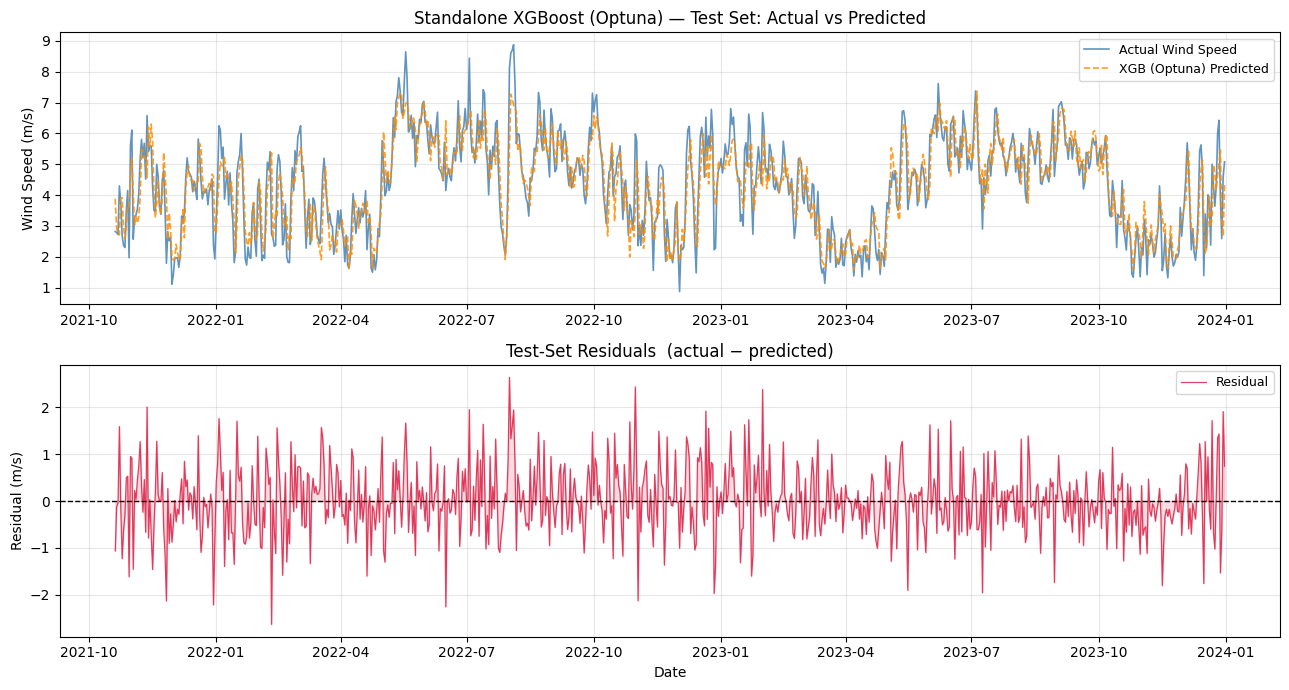

Plot saved: XGB_Standalone_Residuals_Plot.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

# Plot 1: Actual vs Predicted on test set
axes[0].plot(X_test.index, y_test.values,
             label='Actual Wind Speed', color='steelblue', linewidth=1.2, alpha=0.85)
axes[0].plot(X_test.index, y_test_pred,
             label='XGB (Optuna) Predicted', color='darkorange',
             linewidth=1.2, linestyle='--', alpha=0.85)
axes[0].set_title('Standalone XGBoost (Optuna) — Test Set: Actual vs Predicted',
                  fontsize=12)
axes[0].set_ylabel('Wind Speed (m/s)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Test-set residuals
axes[1].plot(X_test.index, test_residuals,
             color='crimson', linewidth=0.9, alpha=0.8, label='Residual')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].fill_between(X_test.index, test_residuals, 0,
                     alpha=0.15, color='crimson')
axes[1].set_title('Test-Set Residuals  (actual − predicted)', fontsize=12)
axes[1].set_ylabel('Residual (m/s)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('XGB_Standalone_Residuals_Plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: XGB_Standalone_Residuals_Plot.png")